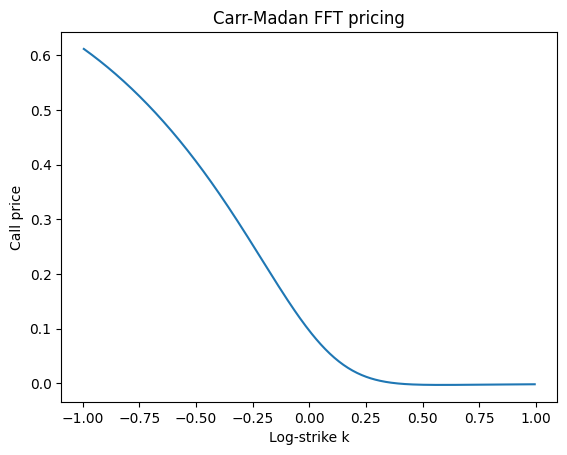

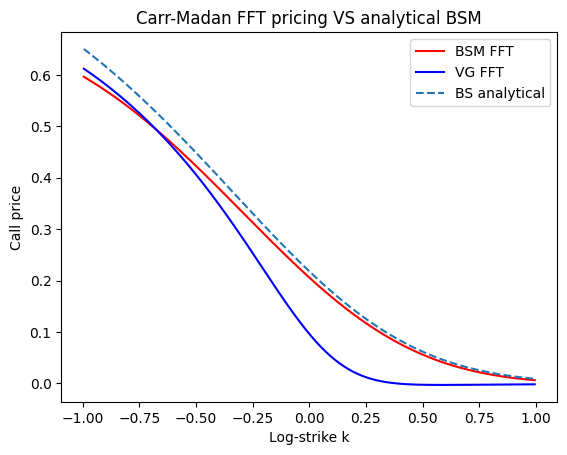

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

N = 5000
eta = 0.25
alpha = 1.5

def C_ITM(r, T, N, S_0, theta, sigma, v, eta, alpha, phi):
    lambda_1 = (2*np.pi)/(N*eta)
    b = 0.5 * N * lambda_1
    k = np.array([-b + lambda_1*(u - 1) for u in range(1,N+1)])
    nu = np.array([eta*(j-1) for j in range(1, N+1)])
    weights = (3 + (-1)**np.arange(N)).astype(float)
    weights[0] = 1
    weights[-1] = 1

    psi = ((np.exp(-r*T))*phi(r, T, S_0, theta, sigma, v, nu - (alpha + 1)*1j))/(alpha**2 + alpha - nu**2 + 1j*(2*alpha + 1)*nu)
    x = np.exp(1j*b*nu)*psi*(eta/3) * weights
    return k, (np.exp(-alpha * k)/np.pi) * np.real(np.fft.fft(x))

#Test VG

S_0 = 1
theta = -0.1
sigma = 0.2
v = 0.1

def phi(r, T, S_0, theta, sigma, v, u):
    omega = (1/v)*np.log(1 - theta * v - 0.5 * sigma**2 * v)
    return np.exp(1j*u*(np.log(S_0) + (r+omega)*T))*(1 - 1j * theta*v*u + 0.5 * sigma**2 * u**2 * v)**(-T/v)

k, C = C_ITM(0.05, 1, N, S_0, theta, sigma, v, eta, alpha, phi)

mask = (k >= -1) & (k <= 1)
plt.plot(k[mask], C[mask])
plt.xlabel('Log-strike k')
plt.ylabel('Call price')
plt.title('Carr-Madan FFT pricing')
plt.show()


#Test BSM

def phi_BSM(r, T, S_0, theta, sigma, v, u):
    return np.exp(1j*u*(np.log(S_0) + (r - 0.5*sigma**2)*T) - 0.5*sigma**2*u**2*T)

k_BSM, C_BSM = C_ITM(0.05, 1, N, S_0, theta, sigma, v, eta, alpha, phi_BSM)

def BS_call(S0, K, r, T, sigma):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

BS_prices = BS_call(S_0, np.exp(k[mask]), 0.05, 1, sigma)
plt.plot(k_BSM[mask], C_BSM[mask], label='BSM FFT', color = 'red')
plt.plot(k[mask], C[mask], label='VG FFT', color = 'blue')
plt.plot(k_BSM[mask], BS_prices, label='BS analytical', linestyle='--')
plt.xlabel('Log-strike k')
plt.ylabel('Call price')
plt.title('Carr-Madan FFT pricing VS analytical BSM')
plt.legend()
plt.show()

